In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/yasserx/blstm-data/metr_la_features.parquet')
df.shape

(34272, 213)

In [3]:
import json

sensor_cols = [col for col in df.columns if col not in 
               ['hour_sin','hour_cos','dow_sin','dow_cos','is_weekend','is_rush_hour']]

print(len(sensor_cols))

with open('/kaggle/working/sensor_ids.json', 'w') as f:
    json.dump(sensor_cols, f)

207


In [4]:
n = len(df)

train_end = int(n * 0.70)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f"Total timestamps : {n:,}")
print(f"Train : {len(train_df):,}  ({len(train_df)/n*100:.1f}%)  {train_df.index[0]} → {train_df.index[-1]}")
print(f"Val   : {len(val_df):,}   ({len(val_df)/n*100:.1f}%)  {val_df.index[0]} → {val_df.index[-1]}")
print(f"Test  : {len(test_df):,}  ({len(test_df)/n*100:.1f}%)  {test_df.index[0]} → {test_df.index[-1]}")

Total timestamps : 34,272
Train : 23,990  (70.0%)  2012-03-01 00:00:00 → 2012-05-23 07:05:00
Val   : 3,427   (10.0%)  2012-05-23 07:10:00 → 2012-06-04 04:40:00
Test  : 6,855  (20.0%)  2012-06-04 04:45:00 → 2012-06-27 23:55:00


In [5]:
test_df.to_parquet('/kaggle/working/metr_la_TEST_raw.parquet')

print(f"  Shape      : {test_df.shape}")
print(f"  Time range : {test_df.index[0]}  →  {test_df.index[-1]}")
print(f"  Timestamps : {len(test_df):,}")

  Shape      : (6855, 213)
  Time range : 2012-06-04 04:45:00  →  2012-06-27 23:55:00
  Timestamps : 6,855


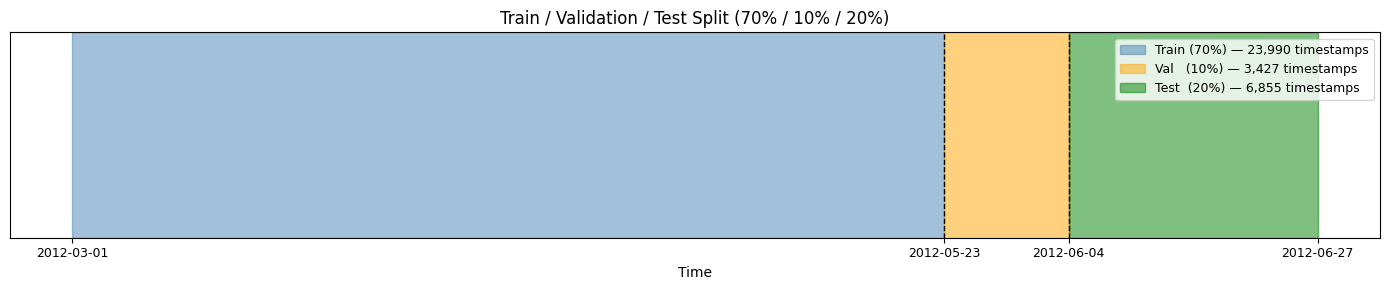

Scaler saved → scaler.pkl

Train speed range after scaling: [0.0000, 1.0000]
Val   speed range after scaling: [-0.2456, 1.0299]
Test  speed range after scaling: [-0.5623, 1.0456]

Feature cols unchanged:
  is_weekend  range: [0, 1]
  hour_sin    range: [-1.0000, 1.0000]


In [6]:
plt.figure(figsize=(14, 3))

plt.axvspan(0,           train_end,  alpha=0.5, color='steelblue', label=f'Train (70%) — {len(train_df):,} timestamps')
plt.axvspan(train_end,   val_end,    alpha=0.5, color='orange',    label=f'Val   (10%) — {len(val_df):,} timestamps')
plt.axvspan(val_end,     n,          alpha=0.5, color='green',     label=f'Test  (20%) — {len(test_df):,} timestamps')

plt.axvline(train_end, color='black', linestyle='--', linewidth=1)
plt.axvline(val_end,   color='black', linestyle='--', linewidth=1)

tick_positions = [0, train_end, val_end, n-1]
tick_labels    = [
    str(df.index[0].date()),
    str(train_df.index[-1].date()),
    str(val_df.index[-1].date()),
    str(df.index[-1].date())
]
plt.xticks(tick_positions, tick_labels, fontsize=9)
plt.yticks([])
plt.xlabel('Time')
plt.title('Train / Validation / Test Split (70% / 10% / 20%)')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_train_val_test_split.png', dpi=300)
plt.show()



speed_cols   = df.columns[:207].tolist()
feature_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[speed_cols])

train_scaled = train_df.copy()
val_scaled   = val_df.copy()
test_scaled  = test_df.copy()

train_scaled[speed_cols] = scaler.transform(train_df[speed_cols])
val_scaled[speed_cols]   = scaler.transform(val_df[speed_cols])
test_scaled[speed_cols]  = scaler.transform(test_df[speed_cols])

joblib.dump(scaler, '/kaggle/working/scaler.pkl')
print("Scaler saved → scaler.pkl")


print(f"\nTrain speed range after scaling: [{train_scaled[speed_cols].values.min():.4f}, {train_scaled[speed_cols].values.max():.4f}]")
print(f"Val   speed range after scaling: [{val_scaled[speed_cols].values.min():.4f}, {val_scaled[speed_cols].values.max():.4f}]")
print(f"Test  speed range after scaling: [{test_scaled[speed_cols].values.min():.4f}, {test_scaled[speed_cols].values.max():.4f}]")
print(f"\nFeature cols unchanged:")
print(f"  is_weekend  range: [{train_scaled['is_weekend'].min()}, {train_scaled['is_weekend'].max()}]")
print(f"  hour_sin    range: [{train_scaled['hour_sin'].min():.4f}, {train_scaled['hour_sin'].max():.4f}]")

In [7]:

input_window  = 12   
output_horizon = 3  

speed_cols = [col for col in train_scaled.columns if col not in
              ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']]

def create_windows(data, input_window, output_horizon, speed_cols):
    X, y = [], []
    
    data_values       = data.values                         
    speed_col_indices = [data.columns.get_loc(c) for c in speed_cols]  
    
    for i in range(len(data) - input_window - output_horizon + 1):
        
        x_window = data_values[i : i + input_window, :] 
        
        y_window = data_values[i + input_window : i + input_window + output_horizon, :]
        y_window = y_window[:, speed_col_indices]
        
        X.append(x_window)
        y.append(y_window)
    
    return np.array(X), np.array(y)


print("Creating sliding windows...")

X_train, y_train = create_windows(train_scaled, input_window, output_horizon, speed_cols)
X_val,   y_val   = create_windows(val_scaled,   input_window, output_horizon, speed_cols)
X_test,  y_test  = create_windows(test_scaled,  input_window, output_horizon, speed_cols)

print(f"\n  X_train shape : {X_train.shape}  (samples, timesteps, features)")
print(f"  y_train shape : {y_train.shape}  (samples, horizon, sensors)")
print(f"\n  X_val shape   : {X_val.shape}")
print(f"  y_val shape   : {y_val.shape}")
print(f"\n  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")

np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/X_val.npy',   X_val)
np.save('/kaggle/working/y_val.npy',   y_val)
np.save('/kaggle/working/X_test.npy',  X_test)
np.save('/kaggle/working/y_test.npy',  y_test)

print(f"\nSaved all windows to /kaggle/working/")

Creating sliding windows...

  X_train shape : (23976, 12, 213)  (samples, timesteps, features)
  y_train shape : (23976, 3, 207)  (samples, horizon, sensors)

  X_val shape   : (3413, 12, 213)
  y_val shape   : (3413, 3, 207)

  X_test shape  : (6841, 12, 213)
  y_test shape  : (6841, 3, 207)

Saved all windows to /kaggle/working/


## BLSTM Model 

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import joblib

In [9]:
print("Loading sliding windows...")
 
X_train = np.load('/kaggle/working/X_train.npy')
y_train = np.load('/kaggle/working/y_train.npy')
X_val   = np.load('/kaggle/working/X_val.npy')
y_val   = np.load('/kaggle/working/y_val.npy')
X_test  = np.load('/kaggle/working/X_test.npy')
y_test  = np.load('/kaggle/working/y_test.npy')
 
print(f"  X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    print(f"  Found {torch.cuda.device_count()} GPUs — using GPU 0 only")
    torch.cuda.set_device(0)
print(f"\n  Device : {device}")

Loading sliding windows...
  X_train : (23976, 12, 213)  y_train : (23976, 3, 207)
  X_val   : (3413, 12, 213)    y_val   : (3413, 3, 207)
  X_test  : (6841, 12, 213)   y_test  : (6841, 3, 207)
  Found 2 GPUs — using GPU 0 only

  Device : cuda


In [10]:
class TrafficDataset(Dataset):
 
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, i):
        return self.X[i], self.y[i]
 
 
# create datasets
train_dataset = TrafficDataset(X_train, y_train)
val_dataset   = TrafficDataset(X_val,   y_val)
test_dataset  = TrafficDataset(X_test,  y_test)
 
batch_size = 64
 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
 
print(f"\n  Batch size       : {batch_size}")
print(f"  Train batches    : {len(train_loader)}")
print(f"  Val batches      : {len(val_loader)}")
print(f"  Test batches     : {len(test_loader)}")


  Batch size       : 64
  Train batches    : 375
  Val batches      : 54
  Test batches     : 107


### BLSTM Class

In [11]:
torch.manual_seed(43)
np.random.seed(43)

class TrafficBLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_steps, output_sensors):
        super(TrafficBLSTM, self).__init__()

        self.hidden_size    = hidden_size
        self.num_layers     = num_layers
        self.output_steps   = output_steps
        self.output_sensors = output_sensors

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout = 0.1
        )

        self.fc = nn.Linear(hidden_size * 2, output_steps * output_sensors)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        out = self.fc(last_out)
        out = out.view(-1, self.output_steps, self.output_sensors)

        return out


input_size     = X_train.shape[2]  
hidden_size    = 128
num_layers     = 2
output_steps   = y_train.shape[1]   
output_sensors = y_train.shape[2]  

model = TrafficBLSTM(input_size, hidden_size, num_layers, output_steps, output_sensors)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Model architecture:")
print(f"    Input size     : {input_size}")
print(f"    Hidden size    : {hidden_size}")
print(f"    LSTM layers    : {num_layers}")
print(f"    Bidirectional  : True")
print(f"    Output steps   : {output_steps}")
print(f"    Output sensors : {output_sensors}")
print(f"    Total params   : {total_params:,}")


  Model architecture:
    Input size     : 213
    Hidden size    : 128
    LSTM layers    : 2
    Bidirectional  : True
    Output steps   : 3
    Output sensors : 207
    Total params   : 906,093


In [12]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-5)

class EarlyStopping:

    def __init__(self, patience=10):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = np.inf
        self.stop       = False

    def check(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), '/kaggle/working/best_model_blstm.pth')
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=10)

print(f"\n  Training setup:")
print(f"    Loss function  : MAE")
print(f"    Optimizer      : Adam  (lr=0.001)")
print(f"    LR scheduler   : ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"    Early stopping : patience=10")
print(f"    Max epochs     : 100")
print(f"    Batch size     : {batch_size}")


  Training setup:
    Loss function  : MAE
    Optimizer      : Adam  (lr=0.001)
    LR scheduler   : ReduceLROnPlateau (patience=5, factor=0.5)
    Early stopping : patience=10
    Max epochs     : 100
    Batch size     : 64


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training data and return average loss."""
    model.train()
    total_loss = 0
 
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
 
        predictions = model(X_batch)
 
        loss = criterion(predictions, y_batch)
 
        optimizer.zero_grad()
        loss.backward()
 
        optimizer.step()
 
        total_loss += loss.item()
 
    return total_loss / len(loader)
 
 
def evaluate(model, loader, criterion, device):
    """Run one full pass over val/test data and return average loss."""
    model.eval()
    total_loss = 0
 
    with torch.no_grad():  
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
 
            predictions = model(X_batch)
            loss        = criterion(predictions, y_batch)
            total_loss += loss.item()
 
    return total_loss / len(loader)

In [14]:
max_epochs  = 100
train_losses = []
val_losses   = []

print(f"\nStarting training...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'LR':>10} {'Time':>8}")
print("-" * 55)

t0 = time.time()

for epoch in range(1, max_epochs + 1):
    t_epoch = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss)

    early_stopping.check(val_loss, model)

    epoch_time = time.time() - t_epoch
    if epoch == 1 or epoch % 10 == 0:
        print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>10.6f} {current_lr:>10.6f} {epoch_time:>7.1f}s")
    
    if early_stopping.stop:
        print(f"\n  Early stopping at epoch {epoch}")
        break

total_time = time.time() - t0
print(f"\n  Training complete in {total_time:.1f}s")
print(f"  Best val loss : {early_stopping.best_loss:.6f}")


Starting training...
 Epoch   Train Loss   Val Loss         LR     Time
-------------------------------------------------------
     1     0.091325   0.058722   0.001000     2.6s
    10     0.044093   0.043734   0.001000     1.7s
    20     0.040856   0.041114   0.001000     1.6s
    30     0.039131   0.040249   0.001000     1.7s
    40     0.038265   0.039469   0.001000     1.6s
    50     0.037393   0.040520   0.001000     1.6s
    60     0.036023   0.038795   0.000500     1.6s
    70     0.035303   0.038767   0.000250     1.6s
    80     0.034952   0.038734   0.000125     1.7s
    90     0.034766   0.038643   0.000063     1.6s
   100     0.034674   0.038692   0.000031     1.6s

  Training complete in 166.7s
  Best val loss : 0.038623


In [15]:
# load best model and compute test loss
model.load_state_dict(torch.load('/kaggle/working/best_model_blstm.pth'))
test_loss = evaluate(model, test_loader, criterion, device)
print(f"  Test loss     : {test_loss:.6f}")

  Test loss     : 0.040111


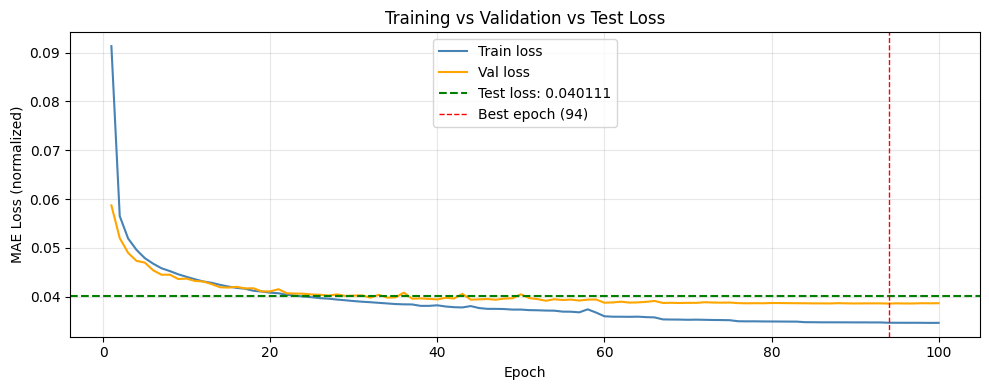

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses,
         linewidth=1.5, color='steelblue', label='Train loss')
plt.plot(range(1, len(val_losses)+1), val_losses,
         linewidth=1.5, color='orange', label='Val loss')
plt.axhline(test_loss, color='green', linestyle='--',
            linewidth=1.5, label=f'Test loss: {test_loss:.6f}')
plt.axvline(np.argmin(val_losses)+1, color='red', linestyle='--',
            linewidth=1, label=f'Best epoch ({np.argmin(val_losses)+1})')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss (normalized)')
plt.title('Training vs Validation vs Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_training_loss_blstm.png', dpi=300)
plt.show()

In [17]:
model.load_state_dict(torch.load('/kaggle/working/best_model_blstm.pth'))
model.eval()
 
scaler = joblib.load('/kaggle/working/scaler.pkl')
 
all_preds  = []
all_targets = []
 
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())
 
all_preds   = np.concatenate(all_preds,   axis=0)   
all_targets = np.concatenate(all_targets, axis=0)  
 

n_samples, n_steps, n_sensors = all_preds.shape
 
preds_2d   = all_preds.reshape(-1, n_sensors)
targets_2d = all_targets.reshape(-1, n_sensors)
 
preds_mph   = scaler.inverse_transform(preds_2d).reshape(n_samples, n_steps, n_sensors)
targets_mph = scaler.inverse_transform(targets_2d).reshape(n_samples, n_steps, n_sensors)

preds_mph = np.clip(preds_mph, 0, 70)

print(f"\n{'Horizon':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 40)
 
horizon_labels = ['5 min', '10 min', '15 min']
for step in range(n_steps):
    p = preds_mph[:, step, :]
    t = targets_mph[:, step, :]
 
    mae  = np.mean(np.abs(p - t))
    rmse = np.sqrt(np.mean((p - t) ** 2))

    mask = t > 5
    mape = np.mean(np.abs((p[mask] - t[mask]) / t[mask])) * 100
 
    print(f"{horizon_labels[step]:<12} {mae:>8.4f} {rmse:>8.4f} {mape:>7.2f}%")
 
mae_total  = np.mean(np.abs(preds_mph - targets_mph))
rmse_total = np.sqrt(np.mean((preds_mph - targets_mph) ** 2))

mask_total = targets_mph > 5
mape_total = np.mean(np.abs((preds_mph[mask_total] - targets_mph[mask_total]) / targets_mph[mask_total])) * 100
 
print(f"\n  Overall MAE  : {mae_total:.4f} mph")
print(f"  Overall RMSE : {rmse_total:.4f} mph")
print(f"  Overall MAPE : {mape_total:.2f}%")


Horizon           MAE     RMSE     MAPE
----------------------------------------
5 min          2.4569   4.5274    6.14%
10 min         2.5978   4.8835    6.58%
15 min         2.7359   5.2295    7.05%

  Overall MAE  : 2.5969 mph
  Overall RMSE : 4.8885 mph
  Overall MAPE : 6.59%


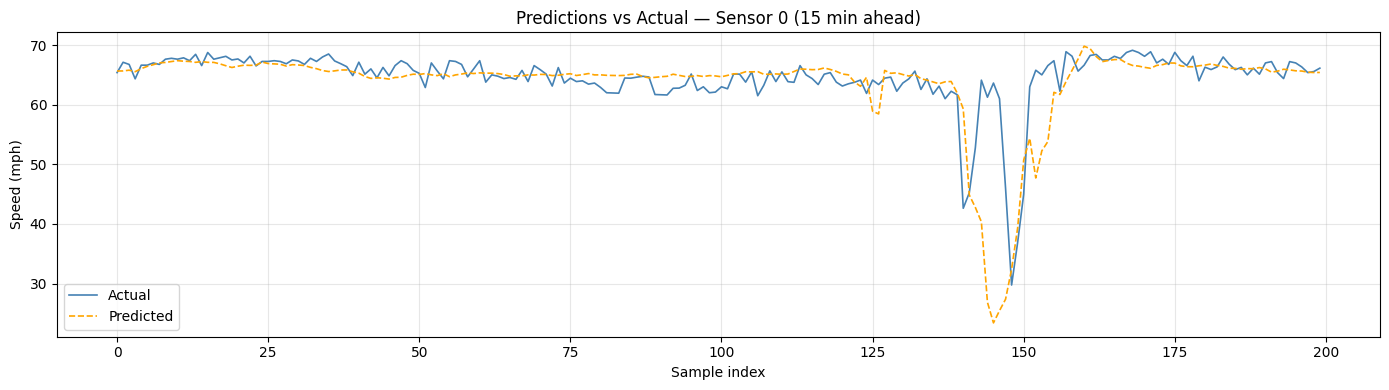

Saved → fig_predictions_vs_actual.png


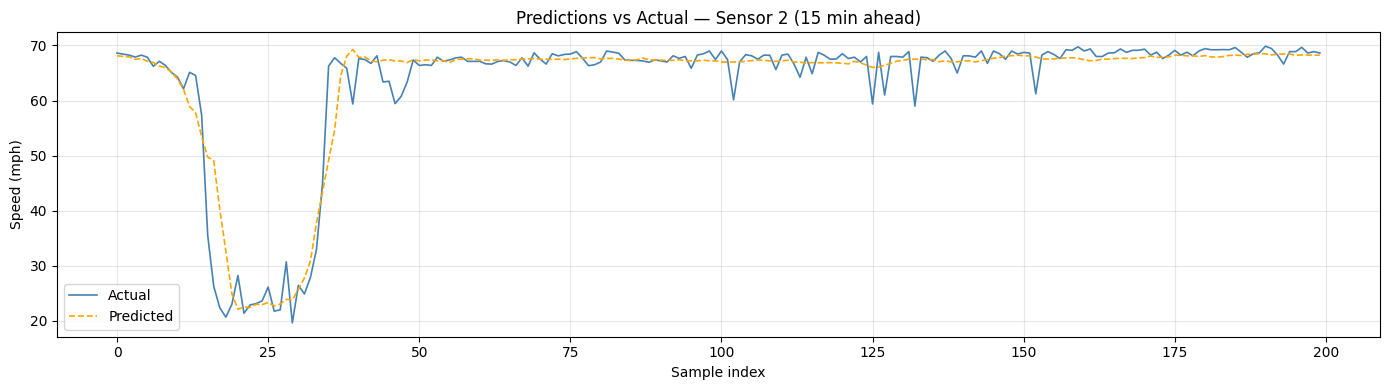

Saved → fig_predictions_vs_actual.png


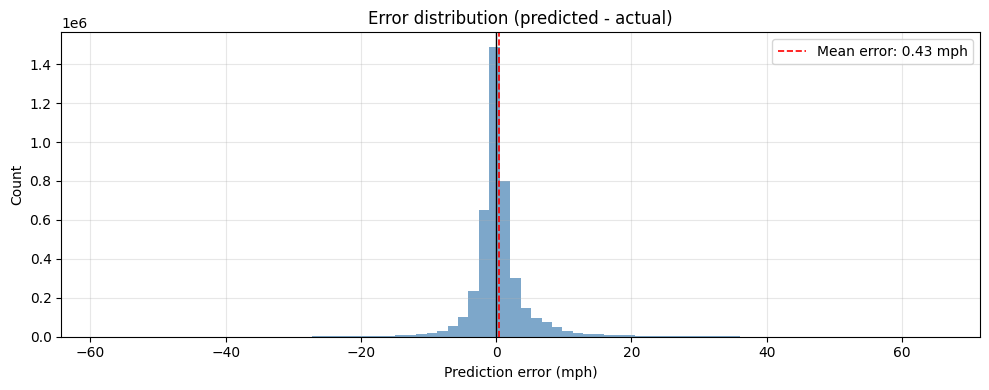

Saved → fig_error_distribution.png


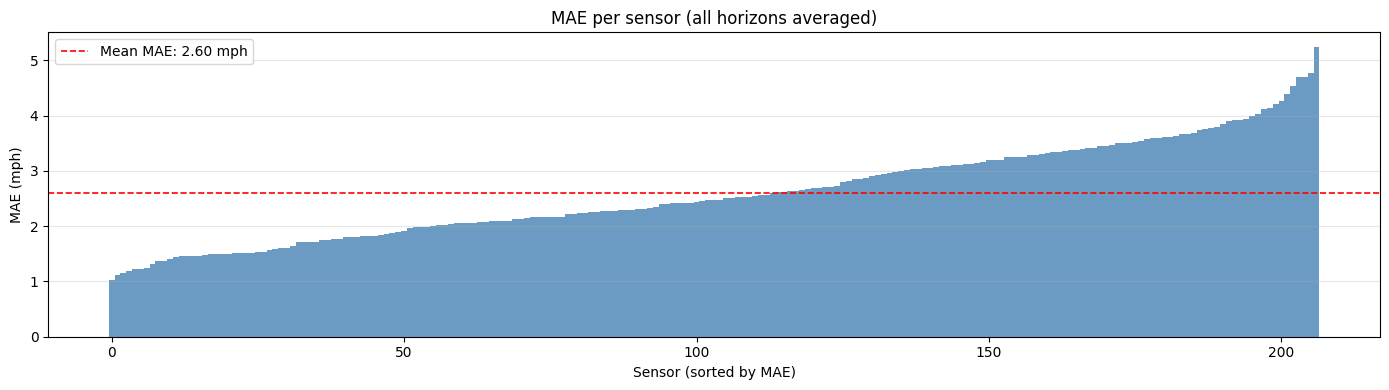

Saved → fig_mae_per_sensor.png


In [18]:

sample_sensor = 0
n_plot        = 200
 
plt.figure(figsize=(14, 4))
plt.plot(range(n_plot), targets_mph[:n_plot, 2, sample_sensor],
         linewidth=1.2, color='steelblue', label='Actual')
plt.plot(range(n_plot), preds_mph[:n_plot, 2, sample_sensor],
         linewidth=1.2, color='orange', linestyle='--', label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Speed (mph)')
plt.title(f'Predictions vs Actual — Sensor {sample_sensor} (15 min ahead)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_predictions_vs_actual.png', dpi=300)
plt.show()
print("Saved → fig_predictions_vs_actual.png")


sample_sensor = 2
n_plot        = 200
 
plt.figure(figsize=(14, 4))
plt.plot(range(n_plot), targets_mph[:n_plot, 2, sample_sensor],
         linewidth=1.2, color='steelblue', label='Actual')
plt.plot(range(n_plot), preds_mph[:n_plot, 2, sample_sensor],
         linewidth=1.2, color='orange', linestyle='--', label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Speed (mph)')
plt.title(f'Predictions vs Actual — Sensor {sample_sensor} (15 min ahead)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_predictions_vs_actual.png', dpi=300)
plt.show()
print("Saved → fig_predictions_vs_actual.png")
 
errors = (preds_mph - targets_mph).flatten()
 
plt.figure(figsize=(10, 4))
plt.hist(errors, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
plt.axvline(0,            color='black', linestyle='-',  linewidth=1)
plt.axvline(errors.mean(), color='red',   linestyle='--', linewidth=1.2,
            label=f'Mean error: {errors.mean():.2f} mph')
plt.xlabel('Prediction error (mph)')
plt.ylabel('Count')
plt.title('Error distribution (predicted - actual)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_error_distribution.png', dpi=300)
plt.show()
print("Saved → fig_error_distribution.png")
 
mae_per_sensor = np.mean(np.abs(preds_mph - targets_mph), axis=(0, 1))
 
plt.figure(figsize=(14, 4))
plt.bar(range(n_sensors), np.sort(mae_per_sensor),
        color='steelblue', alpha=0.8, width=1.0)
plt.axhline(mae_per_sensor.mean(), color='red', linestyle='--',
            linewidth=1.2, label=f'Mean MAE: {mae_per_sensor.mean():.2f} mph')
plt.xlabel('Sensor (sorted by MAE)')
plt.ylabel('MAE (mph)')
plt.title('MAE per sensor (all horizons averaged)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_mae_per_sensor.png', dpi=300)
plt.show()
print("Saved → fig_mae_per_sensor.png")


In [19]:
print("\n" + "="*55)
print("TRAINING COMPLETE BLSTM")
print("="*55)
print(f"  Best val loss  : {early_stopping.best_loss:.6f}")
print(f"  Total epochs   : {len(train_losses)}")
print(f"  Training time  : {total_time:.1f}s")
print(f"\n  Test set results:")
print(f"    MAE  (5 min)  : {np.mean(np.abs(preds_mph[:,0,:] - targets_mph[:,0,:])):.4f} mph")
print(f"    MAE  (10 min) : {np.mean(np.abs(preds_mph[:,1,:] - targets_mph[:,1,:])):.4f} mph")
print(f"    MAE  (15 min) : {np.mean(np.abs(preds_mph[:,2,:] - targets_mph[:,2,:])):.4f} mph")
print(f"    Overall MAE   : {mae_total:.4f} mph")
print(f"    Overall RMSE  : {rmse_total:.4f} mph")
print(f"    Overall MAPE  : {mape_total:.2f}%")
print(f"\n  Saved files:")
print(f"    best_model_blstm.pth")
print(f"    fig_training_loss.png")
print(f"    fig_predictions_vs_actual.png")
print(f"    fig_error_distribution.png")
print(f"    fig_mae_per_sensor.png")


TRAINING COMPLETE BLSTM
  Best val loss  : 0.038623
  Total epochs   : 100
  Training time  : 166.7s

  Test set results:
    MAE  (5 min)  : 2.4569 mph
    MAE  (10 min) : 2.5978 mph
    MAE  (15 min) : 2.7359 mph
    Overall MAE   : 2.5969 mph
    Overall RMSE  : 4.8885 mph
    Overall MAPE  : 6.59%

  Saved files:
    best_model_blstm.pth
    fig_training_loss.png
    fig_predictions_vs_actual.png
    fig_error_distribution.png
    fig_mae_per_sensor.png
